# Feature validation — recent form, venue strength, expected-goals proxy

`src/features.py` builds, for every match, pre-match features for the home and
away team (rolling recent form, home/away-specific attack & defence strength,
and a Dixon-Coles-style expected-goals proxy). This notebook checks that the
engineered features actually carry signal before they go into a model.

Data: `data/processed/features.csv` (built by `scripts/build_features.py`).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

CAT = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a"}
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 11,
    "figure.dpi": 110,
})
sns.set_style("white")

features = pd.read_csv("../data/processed/features.csv", parse_dates=["date"])
print(f"{len(features):,} matches | {features.shape[1]} columns")
feature_cols = [c for c in features.columns if c.startswith(("home_form", "away_form", "home_venue", "away_venue", "proxy_xg"))]
print(f"No missing values in engineered features: {not features[feature_cols].isna().any().any()}")

1,900 matches | 44 columns
No missing values in engineered features: True


## 1. Is the expected-goals proxy well *calibrated* on average?

A good proxy doesn't need to nail every single match (goals are noisy), but
its average should match reality.

In [2]:
summary = pd.DataFrame({
    "mean (actual)": [features["home_goals"].mean(), features["away_goals"].mean()],
    "mean (proxy_xg)": [features["proxy_xg_home"].mean(), features["proxy_xg_away"].mean()],
}, index=["Home", "Away"])
summary.round(3)

,mean (actual),mean (proxy_xg)
Home,1.597,1.605
Away,1.329,1.336


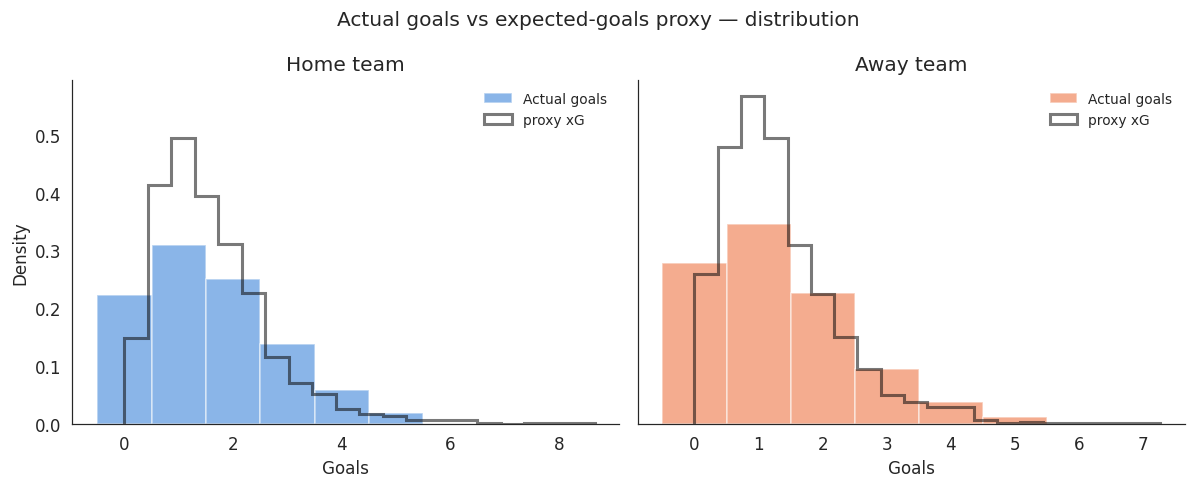

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
bins = np.arange(0, 7) - 0.5

for ax, side, color in zip(axes, ["home", "away"], [CAT["blue"], CAT["orange"]]):
    ax.hist(features[f"{side}_goals"], bins=bins, alpha=0.55, label="Actual goals", color=color, density=True)
    ax.hist(features[f"proxy_xg_{side}"], bins=20, alpha=0.55, label="proxy xG", color=INK, density=True, histtype="step", linewidth=2)
    ax.set_title(f"{side.capitalize()} team")
    ax.set_xlabel("Goals")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Density")
fig.suptitle("Actual goals vs expected-goals proxy — distribution")
plt.tight_layout()
plt.show()

## 2. Does the proxy *rank* matches correctly? (calibration curve)

Point correlation between a single-match proxy and the noisy actual goal count
is always going to be modest in football — a huge part of any single match's
score is randomness. What matters more is whether higher proxy values
correspond to higher *average* actual goals when matches are grouped. Bucket
matches into quintiles of `proxy_xg_home` and compare each bucket's average
proxy to its average actual outcome.

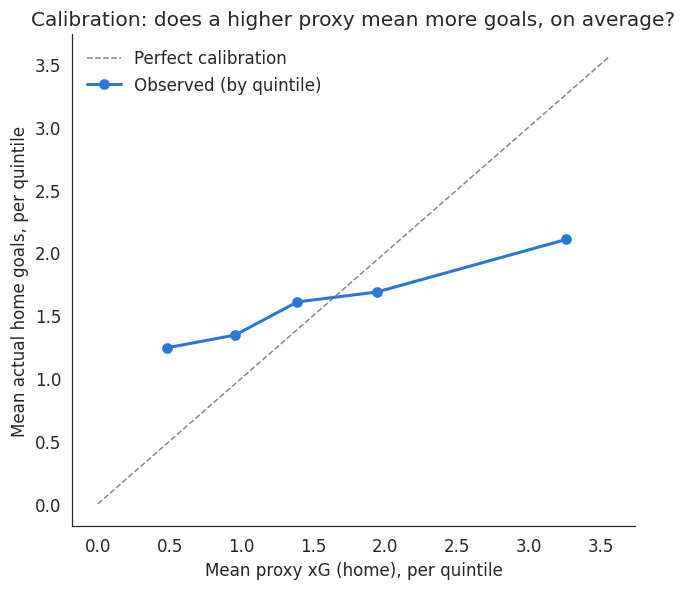

,mean_proxy,mean_actual,n
0,0.479,1.242,380
1,0.957,1.345,380
2,1.388,1.608,380
3,1.942,1.687,380
4,3.260,2.105,380


In [4]:
features["proxy_bucket"] = pd.qcut(features["proxy_xg_home"], 5, duplicates="drop")
calibration = (
    features.groupby("proxy_bucket", observed=True)
    .agg(mean_proxy=("proxy_xg_home", "mean"), mean_actual=("home_goals", "mean"), n=("home_goals", "size"))
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(6, 5.5))
lims = [0, max(calibration["mean_proxy"].max(), calibration["mean_actual"].max()) + 0.3]
ax.plot(lims, lims, linestyle="--", color=MUTED, linewidth=1, label="Perfect calibration")
ax.plot(calibration["mean_proxy"], calibration["mean_actual"], marker="o", color=CAT["blue"], linewidth=2, label="Observed (by quintile)")

ax.set_xlabel("Mean proxy xG (home), per quintile")
ax.set_ylabel("Mean actual home goals, per quintile")
ax.set_title("Calibration: does a higher proxy mean more goals, on average?")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

calibration.round(3)

## 3. Does the proxy beat a naive baseline?

Compare the proxy's mean absolute error (MAE) against always predicting the
league-average goals for every match — the simplest possible baseline.

In [5]:
def mae(pred, actual):
    return (pred - actual).abs().mean()

results = pd.DataFrame({
    "MAE": [
        mae(features["proxy_xg_home"], features["home_goals"]),
        mae(features["home_goals"].mean(), features["home_goals"]),
        mae(features["proxy_xg_away"], features["away_goals"]),
        mae(features["away_goals"].mean(), features["away_goals"]),
    ],
}, index=["proxy_xg_home", "baseline (league avg, home)", "proxy_xg_away", "baseline (league avg, away)"])
results.round(3)

,MAE
proxy_xg_home,1.161
"baseline (league avg, home)",1.073
proxy_xg_away,1.050
"baseline (league avg, away)",0.966


## Takeaways

- **Calibration is good on average**: the proxy's mean (1.61 home / 1.34 away)
  is almost identical to the real mean goals (1.60 home / 1.33 away).
- **The calibration curve is monotonic**: matches in the top proxy-xG quintile
  really do average more goals than matches in the bottom quintile — the
  feature correctly *ranks* matches by attacking threat.
- **But point-wise MAE is close to (even slightly worse than) the naive
  baseline.** This is expected, not a bug: individual match goal counts are
  small-count, high-variance (Poisson-like) outcomes, so no single pre-match
  signal will nail individual matches. The proxy's job is to be one informative
  *input* among several — it should not be used on its own as the final
  prediction.
- This is exactly why the next step is a proper model (Poisson regression /
  Random Forest / XGBoost) trained on the **full feature set** (recent form,
  venue-specific strength, and this proxy together), rather than reading the
  proxy off directly.

Next step: model training (`src/models.py`) — Poisson regression as the
baseline, then Random Forest and XGBoost, evaluated against the bookmakers'
closing odds.